#Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier



#Mount Drive (Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load + clean dataset

In [ ]:
path = "/content/drive/MyDrive/AI project/breast-cancer-wisconsin.data.csv"
df = pd.read_csv(path)

df.columns = (
    df.columns
      .str.lstrip()
      .str.split('  ').str[0]
      .str.replace(':', '', regex=False)
)

df["7. Bare Nuclei"] = df["7. Bare Nuclei"].replace("?", np.nan)
df["7. Bare Nuclei"] = pd.to_numeric(df["7. Bare Nuclei"], errors="coerce")

df = df.drop(columns=["1. Sample code number"])

X = df.drop(columns=["11. Class"])
y = df["11. Class"]

print("X:", X.shape)
print("y distribution:\n", y.value_counts())
print("Missing values per column:\n", X.isna().sum())


X: (699, 9)
y distribution:
 11. Class
2    458
4    241
Name: count, dtype: int64
Missing values per column:
 2. Clump Thickness                 0
3. Uniformity of Cell Size         0
4. Uniformity of Cell Shape        0
5. Marginal Adhesion               0
6. Single Epithelial Cell Size     0
7. Bare Nuclei                    16
8. Bland Chromatin                 0
9. Normal Nucleoli                 0
10. Mitoses                        0
dtype: int64


#Stratified train/test split (test held out)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train dist:\n", y_train.value_counts(normalize=True))
print("Test dist:\n", y_test.value_counts(normalize=True))


Train: (559, 9) Test: (140, 9)
Train dist:
 11. Class
2    0.654741
4    0.345259
Name: proportion, dtype: float64
Test dist:
 11. Class
2    0.657143
4    0.342857
Name: proportion, dtype: float64


#CV setup (Repeated Stratified K-Fold)

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)


#Helper functions

In [ ]:
def show_test_report(model, X_test, y_test, title="Model"):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(f"\n{title} — TEST")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, pred, digits=4))

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f"Class {c}" for c in labels])
    disp.plot()
    plt.show()
    return acc


def tune_and_eval(name, pipe, param_grid):
    gs = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    test_acc = accuracy_score(y_test, best_model.predict(X_test))

    return {
        "name": name,
        "best_params": gs.best_params_,
        "cv_accuracy": gs.best_score_,
        "test_accuracy": test_acc,
        "best_model": best_model
    }


#Define experiments (with & without SMOTE for ALL models)

In [ ]:
experiments = []

# ---------------- Decision Tree ----------------
dt_no = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(random_state=42))
])

dt_sm = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("clf", DecisionTreeClassifier(random_state=42))
])

dt_grid = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [None, 2, 3, 4, 5, 8, 12],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 4, 10],
    "clf__max_features": [None, "sqrt", "log2"]
}

experiments += [
    ("DecisionTree (no SMOTE)", dt_no, dt_grid),
    ("DecisionTree (SMOTE)", dt_sm, dt_grid),
]

# ---------------- Random Forest ----------------
rf_no = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(random_state=42))
])

rf_sm = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

rf_grid = {
    "clf__n_estimators": [300, 800],
    "clf__max_depth": [None, 5, 10],
    "clf__max_features": ["sqrt", "log2", None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__bootstrap": [True, False],
}

experiments += [("RF (no SMOTE)", rf_no, rf_grid),
                ("RF (SMOTE)", rf_sm, rf_grid)]


# ---------------- ExtraTrees ----------------
et_no = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", ExtraTreesClassifier(random_state=42))
])

et_sm = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("clf", ExtraTreesClassifier(random_state=42))
])

et_grid = {
    "clf__n_estimators": [300, 800],
    "clf__max_depth": [None, 5, 10],
    "clf__max_features": ["sqrt", "log2", None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

experiments += [("ExtraTrees (no SMOTE)", et_no, et_grid),
                ("ExtraTrees (SMOTE)", et_sm, et_grid)]


# ---------------- SVM ----------------
svm_no = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC())
])

svm_sm = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("clf", SVC())
])

svm_grid = {
    "clf__kernel": ["rbf", "linear"],
    "clf__C": [0.1, 1, 10, 100, 1000],
    "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
}

experiments += [("SVM (no SMOTE)", svm_no, svm_grid),
                ("SVM (SMOTE)", svm_sm, svm_grid)]


# ---------------- HistGradientBoosting ----------------


hgb_no = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", HistGradientBoostingClassifier(random_state=42))
])

hgb_sm = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("smote", SMOTE(random_state=42)),
    ("clf", HistGradientBoostingClassifier(random_state=42))
])

hgb_grid = {
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_depth": [None, 2, 3, 5],
    "clf__max_iter": [200, 400, 800],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__l2_regularization": [0.0, 0.1, 1.0],
}

experiments += [("HistGB (no SMOTE)", hgb_no, hgb_grid),
                ("HistGB (SMOTE)", hgb_sm, hgb_grid)]

print("Total experiments:", len(experiments))


Total experiments: 10


#Run all tuning and build a ranked results table

In [ ]:
results = []
for name, pipe, grid in experiments:
    res = tune_and_eval(name, pipe, grid)
    results.append(res)
    print(f"{res['name']}: CV={res['cv_accuracy']:.4f} | TEST={res['test_accuracy']:.4f}")

results_df = pd.DataFrame([
    {
        "Model": r["name"],
        "CV Accuracy": r["cv_accuracy"],
        "Test Accuracy": r["test_accuracy"],
        "Best Params": r["best_params"]
    } for r in results
]).sort_values("Test Accuracy", ascending=False)

results_df


DecisionTree (no SMOTE): CV=0.9560 | TEST=0.9214
DecisionTree (SMOTE): CV=0.9556 | TEST=0.9214
RF (no SMOTE): CV=0.9718 | TEST=0.9714
RF (SMOTE): CV=0.9725 | TEST=0.9643
ExtraTrees (no SMOTE): CV=0.9742 | TEST=0.9643
ExtraTrees (SMOTE): CV=0.9778 | TEST=0.9643
SVM (no SMOTE): CV=0.9703 | TEST=0.9571
SVM (SMOTE): CV=0.9728 | TEST=0.9643
HistGB (no SMOTE): CV=0.9696 | TEST=0.9571
HistGB (SMOTE): CV=0.9685 | TEST=0.9571


,Model,CV Accuracy,Test Accuracy,Best Params
2,RF (no SMOTE),0.971750,0.971429,"{'clf__bootstrap': True, 'clf__max_depth': Non..."
3,RF (SMOTE),0.972458,0.964286,"{'clf__bootstrap': True, 'clf__max_depth': 5, ..."
7,SVM (SMOTE),0.972825,0.964286,"{'clf__C': 10, 'clf__gamma': 0.01, 'clf__kerne..."
5,ExtraTrees (SMOTE),0.977828,0.964286,"{'clf__max_depth': 5, 'clf__max_features': 'sq..."
4,ExtraTrees (no SMOTE),0.974247,0.964286,"{'clf__max_depth': None, 'clf__max_features': ..."
6,SVM (no SMOTE),0.970306,0.957143,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker..."
8,HistGB (no SMOTE),0.969614,0.957143,"{'clf__l2_regularization': 0.0, 'clf__learning..."
9,HistGB (SMOTE),0.968533,0.957143,"{'clf__l2_regularization': 0.0, 'clf__learning..."
1,DecisionTree (SMOTE),0.955631,0.921429,"{'clf__criterion': 'gini', 'clf__max_depth': 3..."
0,DecisionTree (no SMOTE),0.956004,0.921429,"{'clf__criterion': 'gini', 'clf__max_depth': 3..."


#Auto-select best model + show full test report

✅ BEST MODEL SELECTED
Model: RF (no SMOTE)
Best CV accuracy: 0.9717503217503217
Best Test accuracy: 0.9714285714285714
Best params: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}

BEST: RF (no SMOTE) — TEST
Accuracy: 0.9714
              precision    recall  f1-score   support

           2     0.9889    0.9674    0.9780        92
           4     0.9400    0.9792    0.9592        48

    accuracy                         0.9714       140
   macro avg     0.9644    0.9733    0.9686       140
weighted avg     0.9721    0.9714    0.9716       140



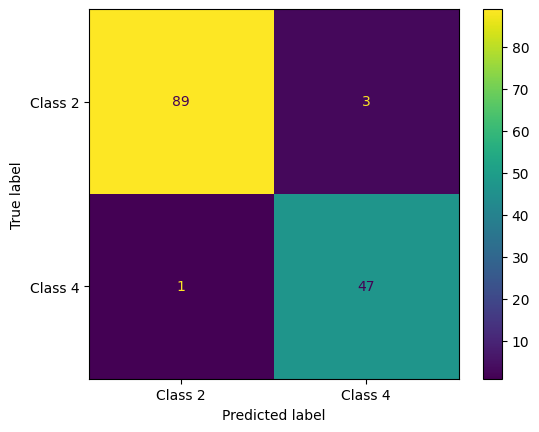

0.9714285714285714

In [ ]:
best_row = results_df.iloc[0]
best_name = best_row["Model"]

best_model = None
best_params = None
best_cv = None
best_test = None

for r in results:
    if r["name"] == best_name:
        best_model = r["best_model"]
        best_params = r["best_params"]
        best_cv = r["cv_accuracy"]
        best_test = r["test_accuracy"]
        break

print("✅ BEST MODEL SELECTED")
print("Model:", best_name)
print("Best CV accuracy:", best_cv)
print("Best Test accuracy:", best_test)
print("Best params:", best_params)

show_test_report(best_model, X_test, y_test, title=f"BEST: {best_name}")


#feature importance visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract the trained Random Forest from the pipeline
rf = best_model.named_steps["clf"]

# 2. Get feature names from training data
feature_names = X_train.columns

# 3. Get feature importances
importances = rf.feature_importances_

# 4. Sort features by importance (descending)
indices = np.argsort(importances)[::-1]

# 5. Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_names[indices], importances[indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance (Best Model)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


NameError: name 'best_model' is not defined